### 定义拟合的目标函数

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def target_function(x):
    """目标函数：带噪声的正弦函数"""
    return torch.sin(x) + 0.1 * torch.randn_like(x)

### 采样建立训练集和测试集

In [4]:
def generate_data(n_samples=1000):
    """生成训练集和测试集"""
    x_train = torch.linspace(-5, 5, n_samples).unsqueeze(1)  # 输入形状 [n_samples, 1]
    y_train = target_function(x_train)
    
    x_test = torch.linspace(-5, 5, n_samples).unsqueeze(1)
    y_test = target_function(x_test)
    
    return (x_train, y_train), (x_test, y_test)

# 生成数据
(x_train, y_train), (x_test, y_test) = generate_data(n_samples=1000)

### 建立模型 -- 一个两个全连接层的Relu网络

In [5]:
class ReLUNet(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, output_dim=1):
        super(ReLUNet, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim) 
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim) 
        self.relu = torch.nn.ReLU()
        
    def forward(self, x):
        self.h1 = self.fc1(x)
        self.h1_relu = self.relu(self.h1) 
        logits = self.fc2(self.h1_relu)
        return logits

# 实例化模型
model = ReLUNet(input_dim=1, hidden_dim=128, output_dim=1)

### 训练模型

In [6]:
# 定义损失函数和优化器
criterion = torch.nn.MSELoss()  # 均方误差损失
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练参数
n_epochs = 2000
train_losses = []
test_losses = []

# 训练循环
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    
    # 前向传播
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    
    # 反向传播和优化
    loss.backward()
    optimizer.step()
    
    # 记录训练损失和测试损失
    train_losses.append(loss.item())
    
    # 测试集验证
    model.eval()
    with torch.no_grad():
        test_outputs = model(x_test)
        test_loss = criterion(test_outputs, y_test)
        test_losses.append(test_loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

Epoch [100/2000], Train Loss: 0.1155, Test Loss: 0.1103
Epoch [200/2000], Train Loss: 0.0292, Test Loss: 0.0279
Epoch [300/2000], Train Loss: 0.0219, Test Loss: 0.0213
Epoch [400/2000], Train Loss: 0.0189, Test Loss: 0.0187
Epoch [500/2000], Train Loss: 0.0174, Test Loss: 0.0173
Epoch [600/2000], Train Loss: 0.0166, Test Loss: 0.0165
Epoch [700/2000], Train Loss: 0.0160, Test Loss: 0.0160
Epoch [800/2000], Train Loss: 0.0156, Test Loss: 0.0156
Epoch [900/2000], Train Loss: 0.0152, Test Loss: 0.0153
Epoch [1000/2000], Train Loss: 0.0148, Test Loss: 0.0150
Epoch [1100/2000], Train Loss: 0.0145, Test Loss: 0.0147
Epoch [1200/2000], Train Loss: 0.0143, Test Loss: 0.0145
Epoch [1300/2000], Train Loss: 0.0140, Test Loss: 0.0143
Epoch [1400/2000], Train Loss: 0.0138, Test Loss: 0.0142
Epoch [1500/2000], Train Loss: 0.0136, Test Loss: 0.0140
Epoch [1600/2000], Train Loss: 0.0134, Test Loss: 0.0138
Epoch [1700/2000], Train Loss: 0.0132, Test Loss: 0.0136
Epoch [1800/2000], Train Loss: 0.0129, T

### 可视化

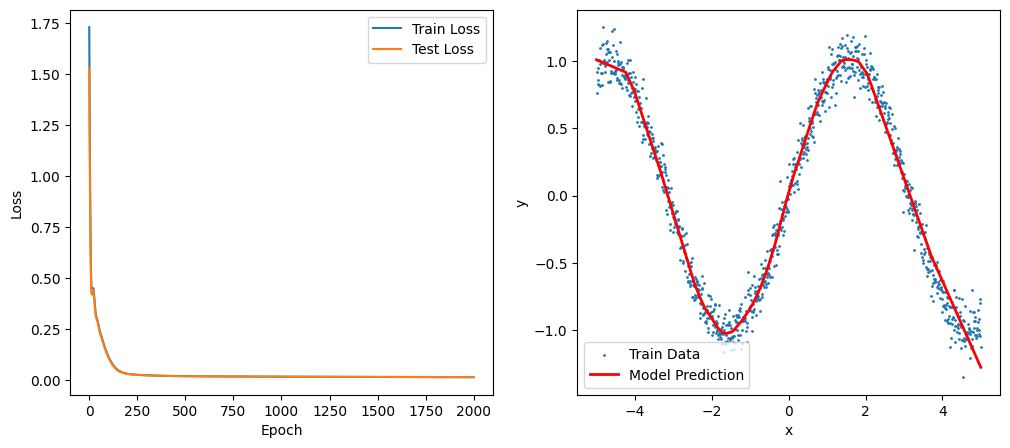

In [7]:
# 绘制损失曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 绘制拟合结果
plt.subplot(1, 2, 2)
with torch.no_grad():
    x_plot = torch.linspace(-5, 5, 1000).unsqueeze(1)
    y_pred = model(x_plot)
    plt.scatter(x_train.numpy(), y_train.numpy(), s=1, label='Train Data')
    plt.plot(x_plot.numpy(), y_pred.numpy(), 'r-', lw=2, label='Model Prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()

plt.show()